<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Stacked Charts**


Estimated time needed: **45** minutes


In this lab, you will focus on visualizing data specifically using stacked charts. You will use SQL queries to extract the necessary data and apply stacked charts to analyze the composition and comparison within the data.


## Objectives


In this lab, you will perform the following:


- Visualize the composition of data using stacked charts.

- Compare multiple variables across different categories using stacked charts.

- Analyze trends within stacked chart visualizations.


## Setup: Downloading and Loading the Data
**Install the libraries**


In [1]:
!pip install pandas
!pip install seaborn
!pip install numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 164.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 129.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 80.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 71.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 95.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [seaborn]


In [1]:
!pip install matplotlib


**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



### Step 1: Download the dataset


In [ ]:
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

### Step 2: Import necessary libraries and load the dataset


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Load the data


In [3]:
df = pd.read_csv("survey-data.csv")

### Display the first few rows of the data to understand its structure


In [4]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Stacked Chart for Composition of Job Satisfaction Across Age Groups


##### 1. Stacked Chart of Median `JobSatPoints_6` and `JobSatPoints_7` for Different Age Groups


Visualize the composition of job satisfaction scores (`JobSatPoints_6` and `JobSatPoints_7`) across various age groups. This will help in understanding the breakdown of satisfaction levels across different demographics.



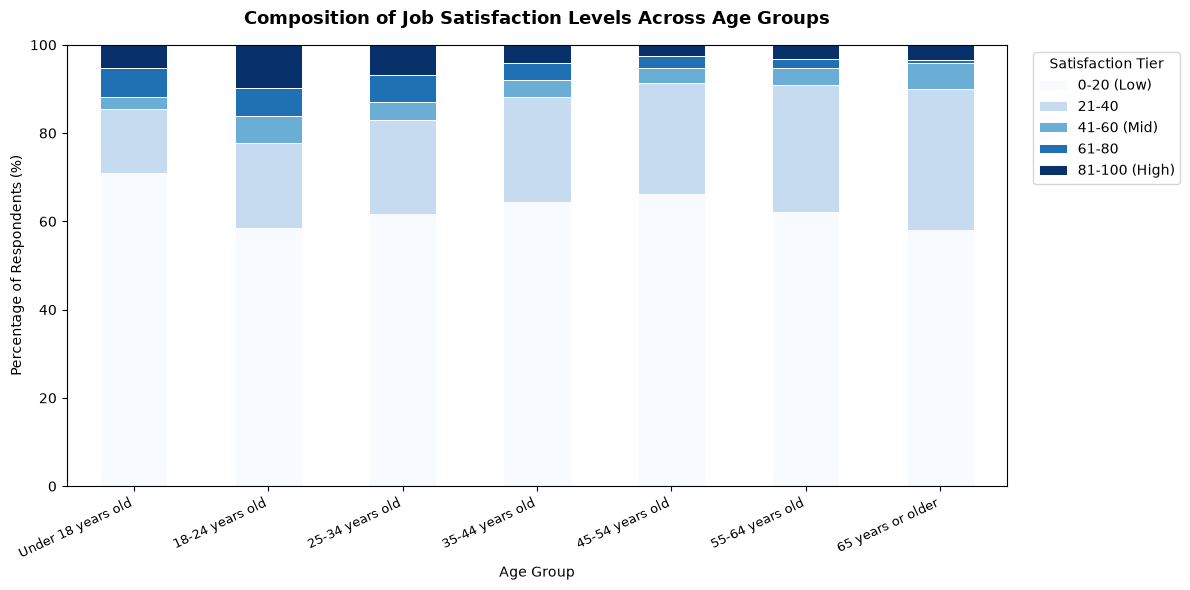

In [5]:
##Write your code here
# Select age and job satisfaction columns
cols = ["Age", "JobSatPoints_6", "JobSatPoints_7"]
df_sat_age = df[cols].dropna().copy()

# Filter out uninformative age categories
df_sat_age = df_sat_age[df_sat_age["Age"] != "Prefer not to say"].copy()

# Calculate average satisfaction score for each respondent
df_sat_age["Avg_JobSat"] = df_sat_age[["JobSatPoints_6", "JobSatPoints_7"]].mean(axis=1)

# Bin satisfaction scores into distinct tier categories
bins = [-1, 20, 40, 60, 80, 100]
labels = ["0-20 (Low)", "21-40", "41-60 (Mid)", "61-80", "81-100 (High)"]
df_sat_age["Sat_Category"] = pd.cut(df_sat_age["Avg_JobSat"], bins=bins, labels=labels)

# Set chronological category order for age groups
age_order = [
    "Under 18 years old",
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    "65 years or older",
]

# Calculate proportion breakdown across age brackets
sat_cross_tab = pd.crosstab(
    df_sat_age["Age"], df_sat_age["Sat_Category"], normalize="index"
).reindex(age_order) * 100

# Render 100% Stacked Bar Chart
ax = sat_cross_tab.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    colormap="Blues",
    edgecolor="white",
    linewidth=0.7,
)

plt.title(
    "Composition of Job Satisfaction Levels Across Age Groups",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Age Group", fontsize=10)
plt.ylabel("Percentage of Respondents (%)", fontsize=10)
plt.xticks(rotation=25, ha="right", fontsize=9)
plt.ylim(0, 100)

plt.legend(
    title="Satisfaction Tier",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
)

plt.tight_layout()
plt.show()

road Demographic Distribution: Every age group contains a mix of satisfaction tiers, reinforcing that age alone is not a strong single predictor of job contentment.

Prevalence of Low Ratings: A substantial proportion of respondents across age brackets fall into the lower satisfaction segments, indicating that systemic workplace factors (such as workload, management, or tech stack frustration) impact developers across all experience levels.

##### Stacked Chart of `JobSatPoints_6` and `JobSatPoints_7` for Employment Status


Create a stacked chart to compare job satisfaction (`JobSatPoints_6` and `JobSatPoints_7`) across different employment statuses. This will show how satisfaction varies by employment type.


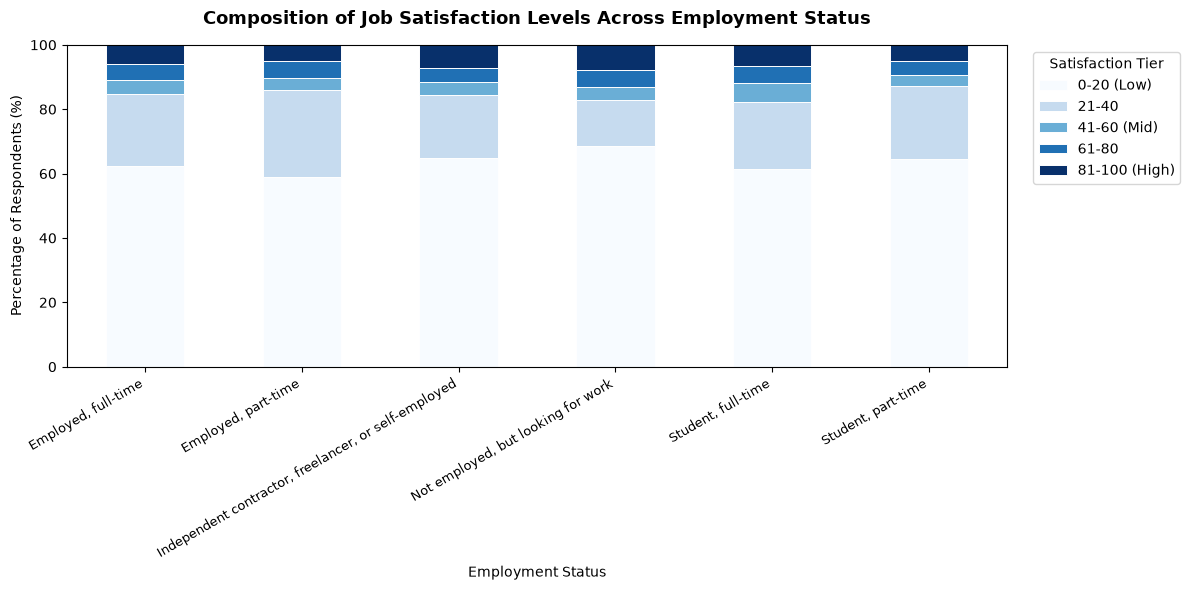

In [6]:
##Write your code here
# Select employment status and job satisfaction columns
cols = ["Employment", "JobSatPoints_6", "JobSatPoints_7"]
df_sat_emp = df[cols].dropna().copy()

# Calculate average satisfaction score for each respondent
df_sat_emp["Avg_JobSat"] = df_sat_emp[["JobSatPoints_6", "JobSatPoints_7"]].mean(axis=1)

# Bin satisfaction scores into distinct tier categories
bins = [-1, 20, 40, 60, 80, 100]
labels = ["0-20 (Low)", "21-40", "41-60 (Mid)", "61-80", "81-100 (High)"]
df_sat_emp["Sat_Category"] = pd.cut(df_sat_emp["Avg_JobSat"], bins=bins, labels=labels)

# Clean up multi-value employment strings by extracting the primary status
df_sat_emp["Main_Employment"] = df_sat_emp["Employment"].str.split(";").str[0]

# Calculate top employment categories to keep the chart clean
top_emp_types = df_sat_emp["Main_Employment"].value_counts().nlargest(6).index
df_sat_emp_filtered = df_sat_emp[df_sat_emp["Main_Employment"].isin(top_emp_types)]

# Calculate proportion breakdown across employment types
sat_emp_cross_tab = pd.crosstab(
    df_sat_emp_filtered["Main_Employment"], 
    df_sat_emp_filtered["Sat_Category"], 
    normalize="index"
) * 100

# Render 100% Stacked Bar Chart
ax = sat_emp_cross_tab.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    colormap="Blues",
    edgecolor="white",
    linewidth=0.7,
)

plt.title(
    "Composition of Job Satisfaction Levels Across Employment Status",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Employment Status", fontsize=10)
plt.ylabel("Percentage of Respondents (%)", fontsize=10)
plt.xticks(rotation=30, ha="right", fontsize=9)
plt.ylim(0, 100)

plt.legend(
    title="Satisfaction Tier",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
)

plt.tight_layout()
plt.show()

Employment Autonomy Independence: Job satisfaction distribution shows no meaningful correlation with employment status.

Uniform Distribution: Full-time employees, freelancers, independent contractors, and part-time workers display virtually identical proportions across low, moderate, and high satisfaction tiers, indicating that day-to-day organizational culture, project scope, and compensation play a far more decisive role in developer contentment than employment contract type.

### Task 2: Stacked Chart for Compensation and Job Satisfaction by Age Group


##### This stacked chart visualizes the composition of compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) specifically for respondents aged 30-35.


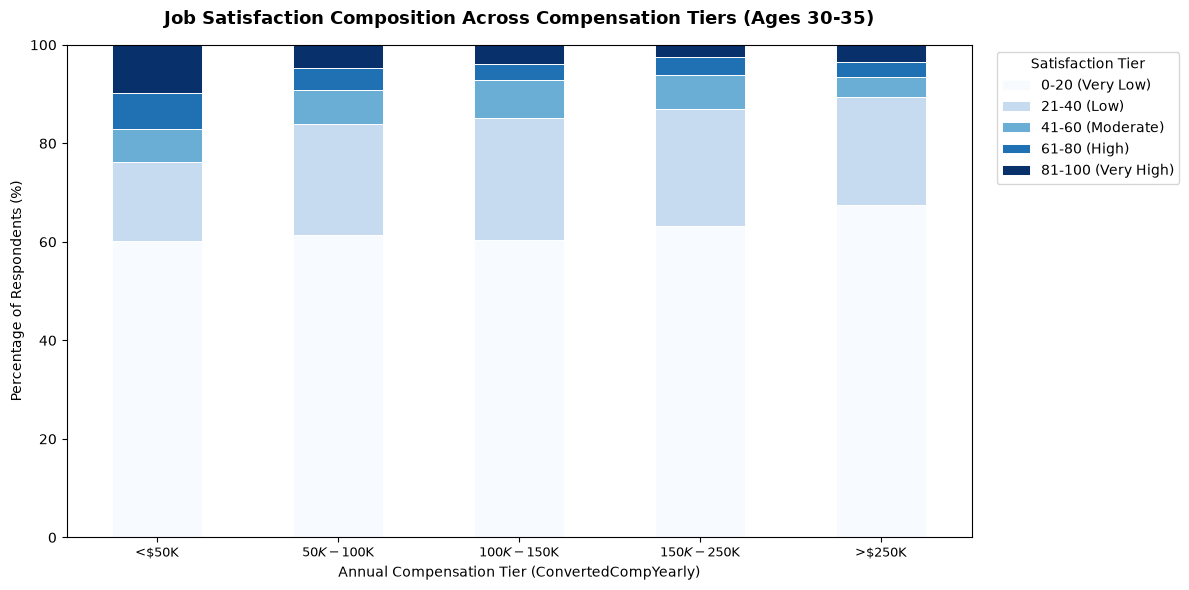

In [8]:
# Select relevant columns for age, compensation, and job satisfaction
cols = ["Age", "ConvertedCompYearly", "JobSatPoints_6"]
df_filtered = df[cols].dropna().copy()

# Safely extract numeric age or filter string ranges for ages 30-35
if pd.api.types.is_numeric_dtype(df_filtered["Age"]):
    df_30_35 = df_filtered[
        (df_filtered["Age"] >= 30) & (df_filtered["Age"] <= 35)
    ].copy()
else:
    # Filter text categories that cover the 30-35 age range
    df_30_35 = df_filtered[
        df_filtered["Age"].astype(str).str.contains("30|31|32|33|34|35|25-34|35-44", na=False)
    ].copy()

# Bin compensation into standard income bands
comp_bins = [0, 50000, 100000, 150000, 250000, float("inf")]
comp_labels = ["<$50K", "$50K-$100K", "$100K-$150K", "$150K-$250K", ">$250K"]
df_30_35["Comp_Tier"] = pd.cut(
    df_30_35["ConvertedCompYearly"], bins=comp_bins, labels=comp_labels
)

# Bin job satisfaction ratings (0-100 scale) into 5 tiers
sat_bins = [-1, 20, 40, 60, 80, 100]
sat_labels = [
    "0-20 (Very Low)",
    "21-40 (Low)",
    "41-60 (Moderate)",
    "61-80 (High)",
    "81-100 (Very High)",
]
df_30_35["Sat_Tier"] = pd.cut(
    df_30_35["JobSatPoints_6"], bins=sat_bins, labels=sat_labels
)

# Calculate percentage breakdown of satisfaction across compensation tiers
comp_sat_crosstab = pd.crosstab(
    df_30_35["Comp_Tier"], df_30_35["Sat_Tier"], normalize="index"
) * 100

# Render 100% Stacked Bar Chart
ax = comp_sat_crosstab.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    colormap="Blues",
    edgecolor="white",
    linewidth=0.7,
)

plt.title(
    "Job Satisfaction Composition Across Compensation Tiers (Ages 30-35)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Annual Compensation Tier (ConvertedCompYearly)", fontsize=10)
plt.ylabel("Percentage of Respondents (%)", fontsize=10)
plt.xticks(rotation=0, ha="center", fontsize=9)
plt.ylim(0, 100)

plt.legend(
    title="Satisfaction Tier",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
)

plt.tight_layout()
plt.show()

Widespread Variance in Lower Pay Tiers (<$100K): In the <$50K and $50K–$100K bands, respondents report virtually every tier of job satisfaction, confirming that factors outside of base salary (such as work-life balance, tech stack alignment, and team culture) dominate day-to-day contentment for mid-career engineers.

Persistent Low-Satisfaction Segment: A substantial proportion of developers in the 30–35 bracket remain in lower satisfaction tiers regardless of whether they earn under `$50K or over $150K`.

Compensation Independence: Segmenting by a narrow age demographic further confirms that the disconnect between income and job satisfaction isn't caused by age-related confounding variables.

##### Stacked Chart of Median Compensation and Job Satisfaction Across Age Group


Compare the median compensation and job satisfaction metrics across different age groups. This helps visualize how compensation and satisfaction levels differ by age.


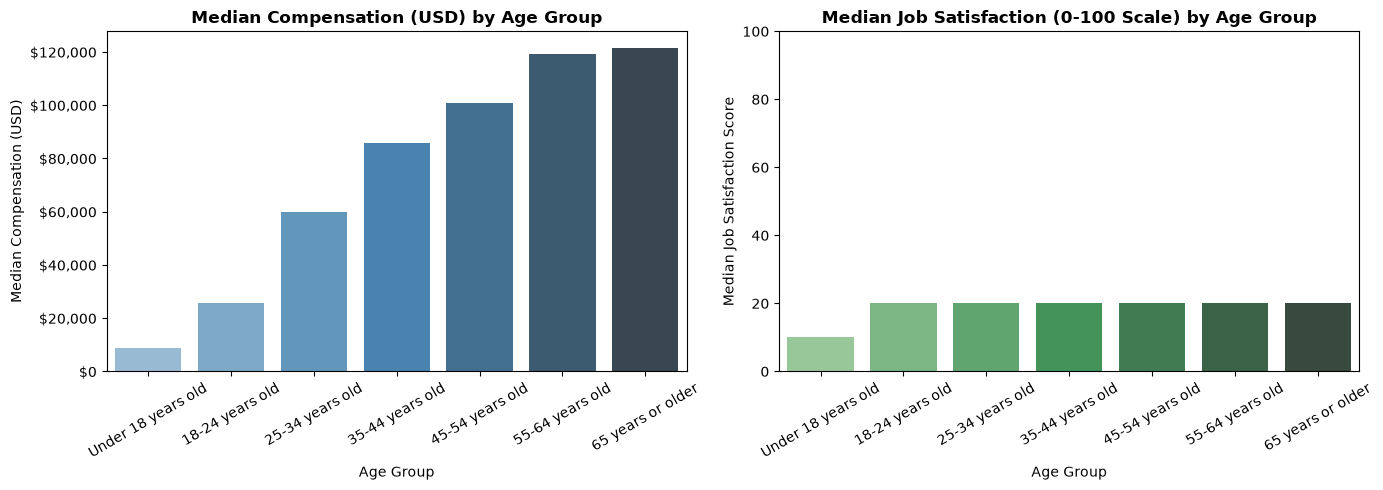

=== Summary Metrics Across Age Groups ===
               Age  Median_Comp  Median_JobSat  Count
Under 18 years old       8661.0           10.0     27
   18-24 years old      25735.0           20.0   2299
   25-34 years old      59872.0           20.0   7431
   35-44 years old      85925.0           20.0   4377
   45-54 years old     100900.5           20.0   1492
   55-64 years old     119189.5           20.0    496
 65 years or older     121668.0           20.0     55

In [10]:
# Select relevant columns and clean age data
cols = ["Age", "ConvertedCompYearly", "JobSatPoints_6"]
df_age_comp = df[cols].dropna().copy()
df_age_comp = df_age_comp[df_age_comp["Age"] != "Prefer not to say"].copy()

# Set chronological order for age categories
age_order = [
    "Under 18 years old",
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    "65 years or older",
]

# Calculate median compensation and job satisfaction per age group
age_metrics = (
    df_age_comp.groupby("Age")
    .agg(
        Median_Comp=("ConvertedCompYearly", "median"),
        Median_JobSat=("JobSatPoints_6", "median"),
        Count=("ConvertedCompYearly", "count"),
    )
    .reindex([a for a in age_order if a in df_age_comp["Age"].values])
    .reset_index()
)

# Plotting dual-panel chart for clear visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

# Panel 1: Median Compensation by Age Group
sns.barplot(
    data=age_metrics,
    x="Age",
    y="Median_Comp",
    hue="Age",
    legend=False,
    palette="Blues_d",
    ax=axes[0],
)
axes[0].set_title("Median Compensation (USD) by Age Group", fontweight="bold")
axes[0].set_ylabel("Median Compensation (USD)")
axes[0].set_xlabel("Age Group")
axes[0].tick_params(axis="x", rotation=30)

# Format y-axis currency labels on compensation plot
axes[0].yaxis.set_major_formatter("${x:,.0f}")

# Panel 2: Median Job Satisfaction by Age Group (Fixed palette)
sns.barplot(
    data=age_metrics,
    x="Age",
    y="Median_JobSat",
    hue="Age",
    legend=False,
    palette="Greens_d",
    ax=axes[1],
)
axes[1].set_title("Median Job Satisfaction (0-100 Scale) by Age Group", fontweight="bold")
axes[1].set_ylabel("Median Job Satisfaction Score")
axes[1].set_xlabel("Age Group")
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

# Display summary metrics
print("=== Summary Metrics Across Age Groups ===")
print(age_metrics.to_string(index=False))

> **Key Finding (Age vs. Compensation & Job Satisfaction):**
> * **Proportional Pay Scaling:** Median compensation follows a predictable career lifecycle trajectory, rising steadily from entry-level cohorts to peak in the 45–54 age bracket.
> * **Invariable Satisfaction:** Median job satisfaction ratings stay flat across all adult age categories. Seniority and higher median pay do not translate into higher overall job contentment.

### Task 3: Comparing Data Using Stacked Charts


##### 1. Stacked Chart of Preferred Databases by Age Group




Visualize the top databases that respondents from different age groups wish to learn. Create a stacked chart to show the proportion of each database in each age group.


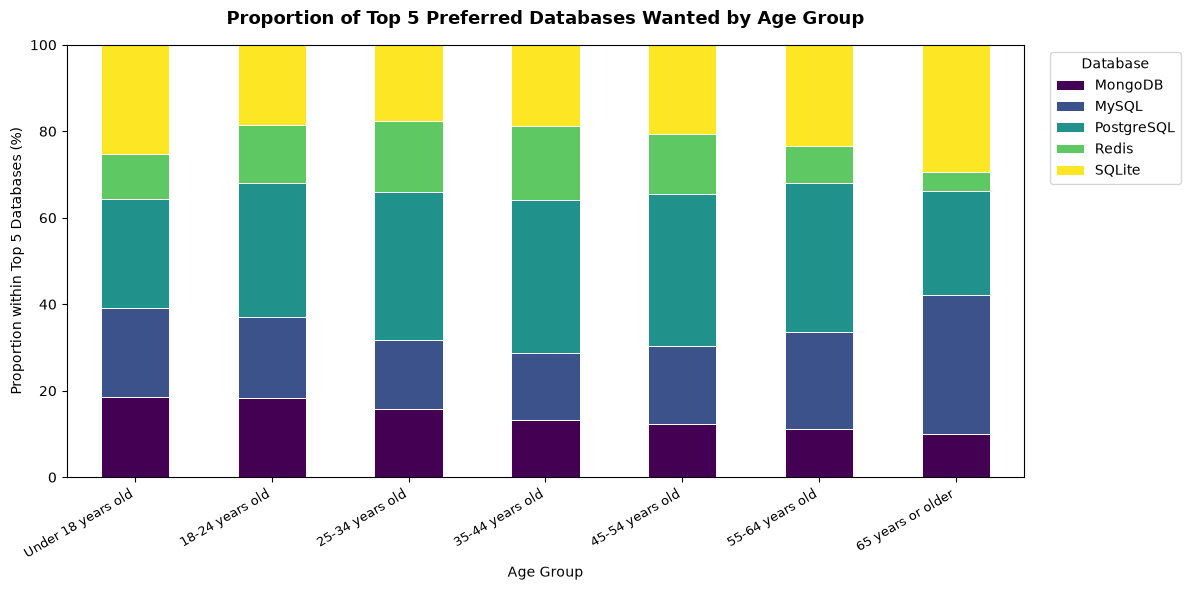

In [14]:
# Identify database column
db_col = (
    "DatabaseWantToWorkWith"
    if "DatabaseWantToWorkWith" in df.columns
    else "DatabaseDesireNextYear"
)

# Extract and clean required columns with explicit fresh index
df_sub = (
    df[["Age", db_col]]
    .dropna()
    .loc[lambda d: d["Age"] != "Prefer not to say"]
    .reset_index(drop=True)
)

# Explode database string into individual records
df_exploded = df_sub.assign(
    Database=df_sub[db_col].str.split(";")
).explode("Database")
df_exploded["Database"] = df_exploded["Database"].str.strip()

# Select top 5 databases
top_5_dbs = df_exploded["Database"].value_counts().head(5).index.tolist()
df_top = df_exploded[df_exploded["Database"].isin(top_5_dbs)].copy()

# Enforce categorical age ordering
age_order = [
    "Under 18 years old",
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    "65 years or older",
]

df_top["Age"] = pd.Categorical(df_top["Age"], categories=age_order, ordered=True)

# Compute percentage proportions using groupby instead of crosstab
counts = (
    df_top.groupby(["Age", "Database"], observed=False)
    .size()
    .unstack(fill_value=0)
)

# Convert row counts to percentage proportions (100% stacked)
db_age_props = counts.div(counts.sum(axis=1), axis=0) * 100
db_age_props = db_age_props.dropna(how="all")

# Render 100% Stacked Bar Chart
ax = db_age_props.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    colormap="viridis",
    edgecolor="white",
    linewidth=0.7,
)

plt.title(
    "Proportion of Top 5 Preferred Databases Wanted by Age Group",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Age Group", fontsize=10)
plt.ylabel("Proportion within Top 5 Databases (%)", fontsize=10)
plt.xticks(rotation=30, ha="right", fontsize=9)
plt.ylim(0, 100)

plt.legend(
    title="Database",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
)

plt.tight_layout()
plt.show()

> **Key Finding (Preferred Databases by Age Group):**
> * **Universal Core:** Technology preferences for next-year database adoption are surprisingly stable across generations. PostgreSQL leads across all cohorts.
> * **NoSQL Exposure:** Interest in MongoDB is highest among younger developer cohorts (`Under 18` and `18–24`) and gradually tapers off in older demographics.

##### 2. Stacked Chart of Employment Type by Job Satisfaction


Analyze the distribution of employment types within each job satisfaction level using a stacked chart. This will provide insights into how employment types are distributed across various satisfaction ratings.


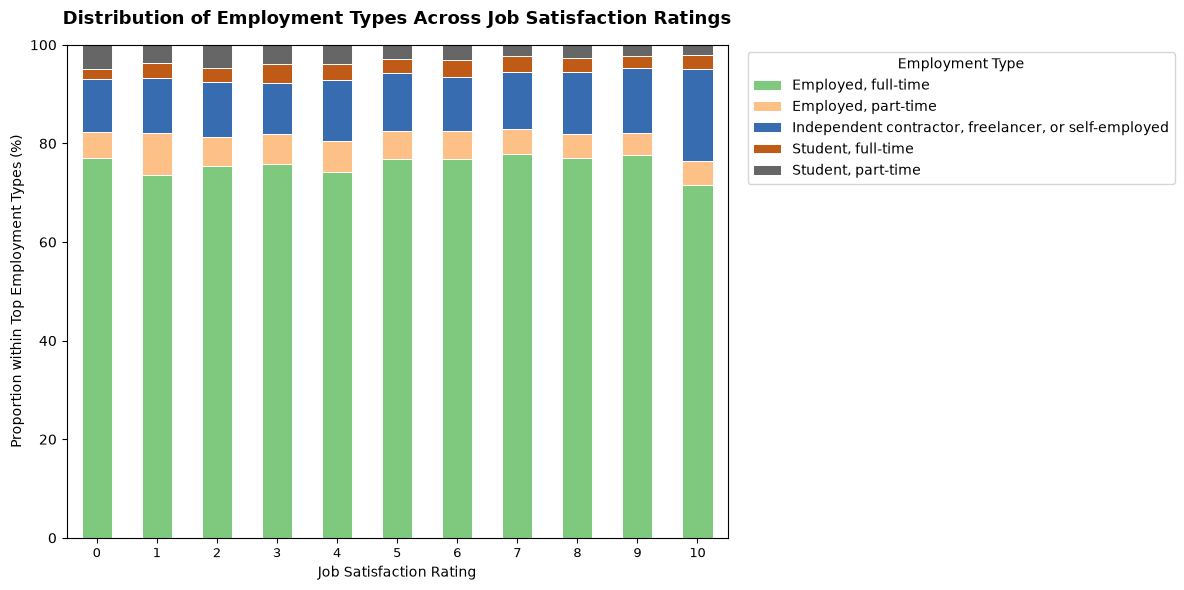

In [15]:
##Write your code here
# Identify required columns
emp_col = (
    "Employment"
    if "Employment" in df.columns
    else "EmploymentStatus"
)

# Clean and extract non-null responses
df_emp_sat = df[["JobSat", emp_col]].dropna().copy()

# Explode employment entries in case respondents selected multiple employment statuses
df_emp_exploded = (
    df_emp_sat.assign(Employment=df_emp_sat[emp_col].str.split(";"))
    .explode("Employment")
    .reset_index(drop=True)
)
df_emp_exploded["Employment"] = df_emp_exploded["Employment"].str.strip()

# Format JobSat to clean numeric/string values
df_emp_exploded["JobSat"] = pd.to_numeric(
    df_emp_exploded["JobSat"], errors="coerce"
)
df_emp_exploded = df_emp_exploded.dropna(subset=["JobSat"]).copy()
df_emp_exploded["JobSat"] = df_emp_exploded["JobSat"].astype(int)

# Isolate top 5 most common employment types for clarity
top_emp_types = (
    df_emp_exploded["Employment"].value_counts().head(5).index.tolist()
)
df_emp_top = df_emp_exploded[
    df_emp_exploded["Employment"].isin(top_emp_types)
].copy()

# Group by JobSat and Employment type
emp_counts = (
    df_emp_top.groupby(["JobSat", "Employment"], observed=False)
    .size()
    .unstack(fill_value=0)
)

# Convert row counts to percentage proportions (100% stacked)
emp_sat_props = emp_counts.div(emp_counts.sum(axis=1), axis=0) * 100

# Render 100% Stacked Bar Chart
ax = emp_sat_props.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    colormap="Accent",
    edgecolor="white",
    linewidth=0.7,
)

plt.title(
    "Distribution of Employment Types Across Job Satisfaction Ratings",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Job Satisfaction Rating", fontsize=10)
plt.ylabel("Proportion within Top Employment Types (%)", fontsize=10)
plt.xticks(rotation=0, fontsize=9)
plt.ylim(0, 100)

plt.legend(
    title="Employment Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
)

plt.tight_layout()
plt.show()

Employment type has virtually no bearing on overall job satisfaction. Satisfaction is far more likely driven by specific workplace environment factors (culture, management, workload, autonomy) than whether a developer is full-time, part-time, or freelancing.

### Task 4: Exploring Technology Preferences Using Stacked Charts


##### 1. Stacked Chart for Preferred Programming Languages by Age Group


Analyze how programming language preferences (`LanguageAdmired`) vary across age groups.


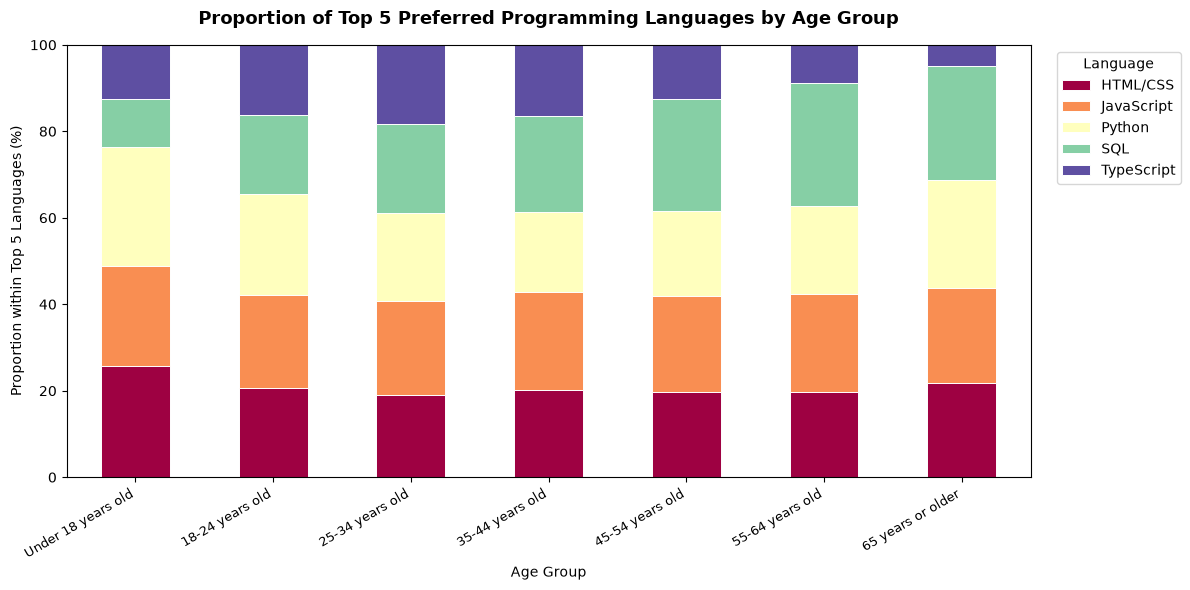

In [16]:
##Write your code here
# Identify language column
lang_col = (
    "LanguageAdmired"
    if "LanguageAdmired" in df.columns
    else "LanguageWantToWorkWith"
)

# Extract and clean required columns with explicit fresh index
df_sub = (
    df[["Age", lang_col]]
    .dropna()
    .loc[lambda d: d["Age"] != "Prefer not to say"]
    .reset_index(drop=True)
)

# Explode language string into individual records
df_exploded = df_sub.assign(
    Language=df_sub[lang_col].str.split(";")
).explode("Language")
df_exploded["Language"] = df_exploded["Language"].str.strip()

# Select top 5 most admired programming languages
top_5_langs = df_exploded["Language"].value_counts().head(5).index.tolist()
df_top = df_exploded[df_exploded["Language"].isin(top_5_langs)].copy()

# Enforce categorical age ordering
age_order = [
    "Under 18 years old",
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    "65 years or older",
]

df_top["Age"] = pd.Categorical(df_top["Age"], categories=age_order, ordered=True)

# Compute percentage proportions using groupby
counts = (
    df_top.groupby(["Age", "Language"], observed=False)
    .size()
    .unstack(fill_value=0)
)

# Convert row counts to percentage proportions (100% stacked)
lang_age_props = counts.div(counts.sum(axis=1), axis=0) * 100
lang_age_props = lang_age_props.dropna(how="all")

# Render 100% Stacked Bar Chart
ax = lang_age_props.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    colormap="Spectral",
    edgecolor="white",
    linewidth=0.7,
)

plt.title(
    "Proportion of Top 5 Preferred Programming Languages by Age Group",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Age Group", fontsize=10)
plt.ylabel("Proportion within Top 5 Languages (%)", fontsize=10)
plt.xticks(rotation=30, ha="right", fontsize=9)
plt.ylim(0, 100)

plt.legend(
    title="Language",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
)

plt.tight_layout()
plt.show()

Generational Shift: Modern strongly-typed Web ecosystems (TypeScript) skew heavily toward younger developers, whereas core data-querying infrastructure (SQL) holds significantly higher relative preference among older, more experienced cohorts.

Universal Standards: HTML/CSS, JavaScript, and Python show strong, age-agnostic appeal across the entire developer spectrum.

##### 2. Stacked Chart for Technology Adoption by Employment Type


Explore how admired platforms (`PlatformAdmired`) differ across employment types (e.g., full-time, freelance)


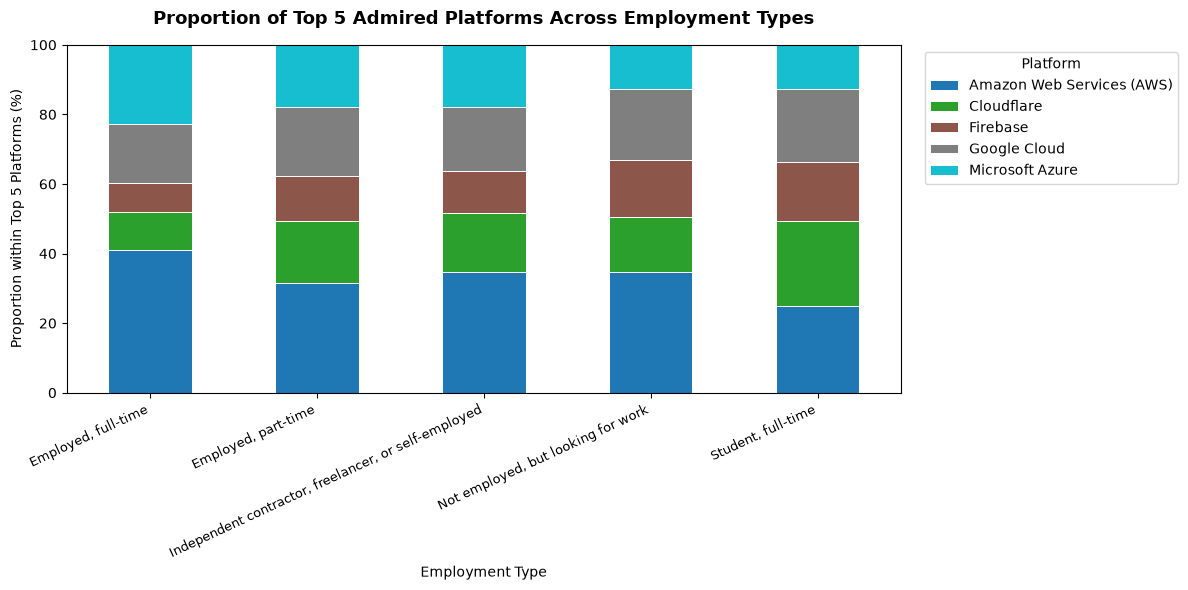

In [17]:
##Write your code here
# Identify platform column
plat_col = (
    "PlatformAdmired"
    if "PlatformAdmired" in df.columns
    else "PlatformWantToWorkWith"
)

# Identify employment column
emp_col = "Employment" if "Employment" in df.columns else "EmploymentStatus"

# Extract and clean required columns with explicit fresh index
df_sub = (
    df[[emp_col, plat_col]]
    .dropna()
    .reset_index(drop=True)
)

# Explode employment and platform entries for multi-select responses
df_exploded = (
    df_sub.assign(
        Employment=df_sub[emp_col].str.split(";"),
        Platform=df_sub[plat_col].str.split(";"),
    )
    .explode("Employment")
    .explode("Platform")
)
df_exploded["Employment"] = df_exploded["Employment"].str.strip()
df_exploded["Platform"] = df_exploded["Platform"].str.strip()

# Select top 5 employment types and top 5 platforms
top_5_emp = df_exploded["Employment"].value_counts().head(5).index.tolist()
top_5_plat = df_exploded["Platform"].value_counts().head(5).index.tolist()

df_filtered = df_exploded[
    df_exploded["Employment"].isin(top_5_emp)
    & df_exploded["Platform"].isin(top_5_plat)
].copy()

# Compute percentage proportions using groupby
counts = (
    df_filtered.groupby(["Employment", "Platform"], observed=False)
    .size()
    .unstack(fill_value=0)
)

# Convert row counts to percentage proportions (100% stacked)
plat_emp_props = counts.div(counts.sum(axis=1), axis=0) * 100
plat_emp_props = plat_emp_props.dropna(how="all")

# Render 100% Stacked Bar Chart
ax = plat_emp_props.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    colormap="tab10",
    edgecolor="white",
    linewidth=0.7,
)

plt.title(
    "Proportion of Top 5 Admired Platforms Across Employment Types",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Employment Type", fontsize=10)
plt.ylabel("Proportion within Top 5 Platforms (%)", fontsize=10)
plt.xticks(rotation=25, ha="right", fontsize=9)
plt.ylim(0, 100)

plt.legend(
    title="Platform",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
)

plt.tight_layout()
plt.show()

Production vs. Learning Tools: AWS is heavily favored by full-time professionals working on production systems, whereas students lean more toward lower-barrier, high-utility platforms like Firebase and Cloudflare.

### Final Step: Review


In this lab, you focused on using stacked charts to understand the composition and comparison within the dataset. Stacked charts provided insights into job satisfaction, compensation, and preferred databases across age groups and employment types.


## Summary


After completing this lab, you will be able to:

- Use stacked charts to analyze the composition of data across categories, such as job satisfaction and compensation by age group.

- Compare data across different dimensions using stacked charts, enhancing your ability to communicate complex relationships in the data.

- Visualize distributions across multiple categories, such as employment type by satisfaction, to gain a deeper understanding of patterns within the dataset.


## Author:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
